In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Análisis exploratorio de datos

In [23]:
df_diabetes = pd.read_csv("./diabetes.csv")
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [24]:
# Eliminamos la columna "Unnamed: 0", que es solo un índice residual del csv y no aporta información
df_diabetes = df_diabetes.drop(columns=["Unnamed: 0"])
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [25]:
print("Número de instancias:", df_diabetes.shape[0])
print("Número total de columnas:", df_diabetes.shape[1])
print("Número de atributos predictores:", df_diabetes.shape[1] - 1)

Número de instancias: 768
Número total de columnas: 9
Número de atributos predictores: 8


- ¿Cuál es la variable objetivo (target) y qué representa cada uno de sus valores?

    La *variable objetivo* (target) es la variable **"Outcome"**, y sus variables 1 y 0 representan si la paciente presenta o no diabetes respectivamente 
- ¿Qué representa cada **fila** del dataset?

    Cada **fila** del dataset representa a una paciente distinta
- ¿Qué representa cada **columna**?

    Cada una de las **columnas** del dataset representa una variable clínica distinta, estas pueden ser: número de embarazos, nivel de glucosa en sangre, presión arterial, nivel de insulina, edad, entre otras.

- ¿Qué tipo de problema de aprendizaje automático es este: **clasificación** o **regresión**? Justificá por qué.

    Este dataset representa un **problema de clasificación**. Esto se debe a que la variable objetivo, "Outcome", no es una medida continua sino una etiqueta categórica que solo puede tomar dos valores posibles: 0 (paciente sin diabetes) o 1 (paciente con diabetes). El objetivo del modelo no es predecir una cantidad (como ocurriría en un problema de regresión, por ej. al estimar el precio de una vivienda), sino determinar a cuál de dos clases mutuamente excluyentes pertenece cada paciente en función de sus mediciones clínicas (glucosa, presión arterial, BMI, edad, etc.). Además, aunque Outcome esté codificado numéricamente (0 y 1), estos números no representan una escala ordinal ni una cantidad, ya que no existe un valor intermedio entre tener y no tener diabetes, lo cual confirma que es categórica y, por lo tanto, que se trata de un problema de clasificación

## 2. Exploración inicial de los datos

Observamos los atributos existentes y el número de instancias de cada uno

In [26]:
df_diabetes.info() 

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             767 non-null    float64
 3   SkinThickness             756 non-null    float64
 4   Insulin                   763 non-null    float64
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


**Observamos las categorías de los atributos categórico**

In [27]:
df_diabetes["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- ¿Qué tipos de datos aparecen en el dataset (enteros, flotantes, etc.)? ¿Hay columnas categóricas?

    En el dataset aparecen datos enteros y flotantes. La unica columna categórica es "Outcome", que indica si la paciente presenta diabetes o no.

**Analizamos si hay valores faltantes**

In [28]:
df_diabetes.isnull().sum() #Se cuentan todos los NaN por columna, para ver si hay valores faltantes en el dataset

Pregnancies                  0
Glucose                      0
BloodPressure                1
SkinThickness               12
Insulin                      5
BMI                          1
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

- ¿Existen valores faltantes (NaN) en el dataset? 

    Como es posible observar, las columnas "BloodPressure", "SkinThinckness", "Insulin" y "BMI" presentan valores faltantes

**Resúmen estadístico de los atributos numéricos**

In [29]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [30]:
df_diabetes.median() #Se obtiene un resumen estadístico de las columnas num

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      36.0000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

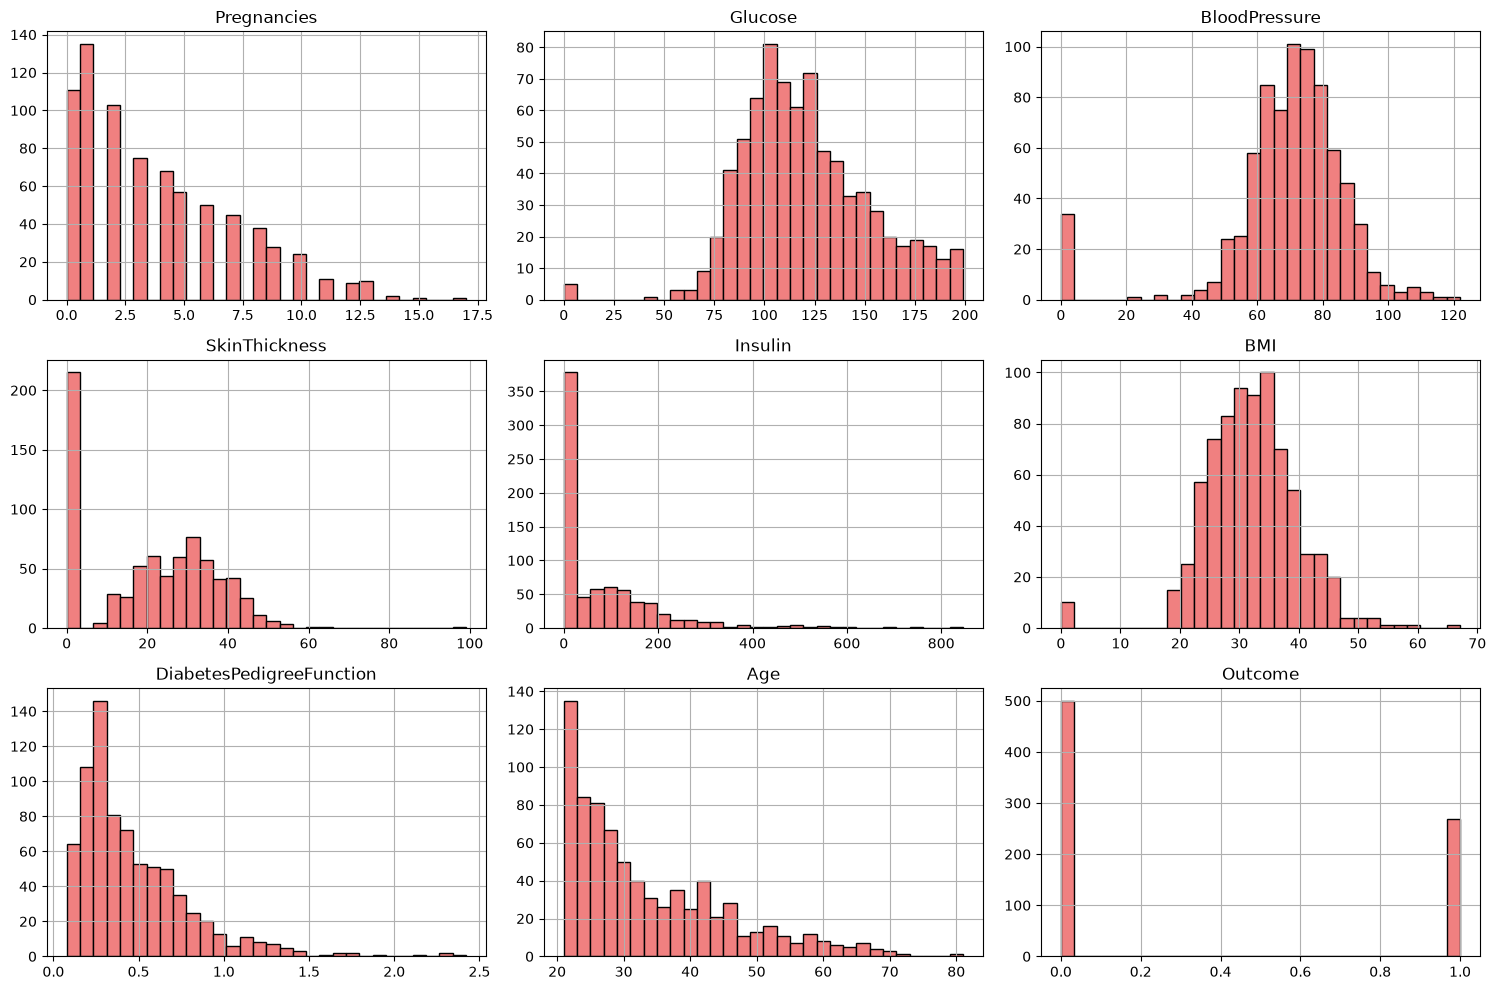

In [31]:
df_diabetes.hist(bins=30, figsize=(15, 10), edgecolor="k", color= "lightcoral") #Genera histogramas para cada atributo del dataset
plt.tight_layout()
plt.show()

- ¿Existen variables con **distribuciones sesgadas**? ¿Cuáles y hacia qué lado?
   
    Como se puese observar en los histogramas, las variables Pregnancies, Age, DiabetesPedigreeFuction e Insulin presentan una **distribución sesgada** hacia la derecha. 

- ¿Existen variables con **escalas muy diferentes** entre sí? 
   
    Sí **existen escalas muy diferentes entre sí**, por ej, Insulin llega a valores de varios cientos, mientras que DiabetesPedigreeFunction no supera 2.5. Esta diferencia de escala hace necesario aplicar un escalado antes de usar los datos en un modelo.

## 3. División del dataset en entrenamiento y prueba

Se deben separar los datos en dos partes debido a que, de esta manera es posible conocer si el modelo realmente aprendió a partir de los datos. Si entrenáramos y evaluáramos con los mismos datos, no sabríamos si el modelo realmente aprendió el patrón clínico de la diabetes o si simplemente "memorizó" esos casos puntuales.

In [32]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    df_diabetes, test_size=0.2, stratify=df_diabetes["Outcome"], random_state=42
)

print("Train:", train_set.shape)
print("Test:", test_set.shape)
print()
print("Proporción de Outcome en train:")
print(train_set["Outcome"].value_counts(normalize=True))
print()
print("Proporción de Outcome en test:")
print(test_set["Outcome"].value_counts(normalize=True))

Train: (614, 9)
Test: (154, 9)

Proporción de Outcome en train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Proporción de Outcome en test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


Para dividir los datos se utilizó **train_test_split** con un test_size de 0.2, reservando el **20%** de las pacientes para el conjunto de **prueba** y el **80%** para **entrenamiento**. Como la variable "Outcome" presenta un desbalance de clases (65% sin diabetes, 35% con diabetes), se aplicó **muestreo estratificado** (stratify=Outcome) para garantizar que ambos subconjuntos (entrenamiento y prueba) mantuvieran una proporción similar de pacientes con y sin diabetes, evitando así que el azar generara una división poco representativa. Se fijó además random_state=42 para asegurar la reproducibilidad del split

A partir de esta sección solo **vamos a trabajar con train_set**, los datos en test_set se van a guardar y soló serán utilizados cuando se evalue el modelo

In [33]:
# Hacemos una copia de trabajo del conjunto de entrenamiento
diabetes_train = train_set.copy()

 ## 4. Análisis de posibles problemas en los datos

In [34]:
invalid_zero_col = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] # Columnas donde no se esperan valores cero

zero_counts = (diabetes_train[invalid_zero_col] == 0).sum() #numero de ceros por columna

print("Ceros detectados en columnas médicas que no pueden ser cero en condiciones reales:")
for col in invalid_zero_col:
    print(f" - {col}: {zero_counts[col]}")

print("\nCeros por Outcome:")
zero_outcome = diabetes_train.groupby("Outcome")[invalid_zero_col].apply(lambda g: (g == 0).sum())
print(zero_outcome)


Ceros detectados en columnas médicas que no pueden ser cero en condiciones reales:
 - Glucose: 4
 - BloodPressure: 22
 - SkinThickness: 164
 - Insulin: 285
 - BMI: 8

Ceros por Outcome:
         Glucose  BloodPressure  SkinThickness  Insulin  BMI
Outcome                                                     
0              2             11            102      182    7
1              2             11             62      103    1


Las variables **Glucose, BloodPressure, SkinThinkness, Insulin y BMI** no pueden tomar valores cero, y es por ello que, si toman ese valor se considera que es una error o dato faltante, ya que son *variables invalidas, no mediciones reales*.
Para tratar estos errores podemos **convertir esos ceros en NAN** e **imputarlos utilizando mediana global**, ya que si hacemos la imputación utilizando Outcome, se complica al agregar un nuevo paciente y además hay una fuga de información al momento de validación o prueba.

A continuación se muestra la **estrategia de imputación condicionada por Outcome**:

In [35]:
# Calculamos las medianas por grupo de Outcome
medianas_outcome = diabetes_train.groupby("Outcome")[invalid_zero_col].median()
print("\nMedianas por Outcome:")
print(medianas_outcome)

# Crea una copia para la imputación condicionada
diabetes_train_imputacion_cond = diabetes_train.copy()

# Convertimos ceros en NaN primero
for col in invalid_zero_col:
    diabetes_train_imputacion_cond.loc[diabetes_train_imputacion_cond[col] == 0, col] = np.nan

# Imputamos usando medianas por Outcome
for outcome_value in diabetes_train_imputacion_cond["Outcome"].unique():
    mask = diabetes_train_imputacion_cond["Outcome"] == outcome_value
    for col in invalid_zero_col:
        median_val = medianas_outcome.loc[outcome_value, col]
        diabetes_train_imputacion_cond.loc[mask, col] = diabetes_train_imputacion_cond.loc[mask, col].fillna(median_val)

print("\nDatos después de imputación condicionada:")
print(diabetes_train_imputacion_cond[invalid_zero_col].describe())



Medianas por Outcome:
         Glucose  BloodPressure  SkinThickness  Insulin   BMI
Outcome                                                      
0          108.0           70.0           22.0     42.0  30.1
1          141.0           74.0           28.0     56.0  34.3

Datos después de imputación condicionada:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean   121.719870      72.136808      27.701954  100.897394   32.428176
std     30.031843      12.281268       9.280165   93.157172    6.829521
min     56.000000      24.000000       7.000000   15.000000   18.200000
25%     99.000000      64.000000      22.000000   42.000000   27.625000
50%    117.000000      72.000000      28.000000   56.000000   32.400000
75%    141.000000      80.000000      32.000000  130.000000   36.500000
max    199.000000     122.000000      99.000000  744.000000   67.100000


Ahora, hacemos la **estrategia de imputación global**:

In [36]:
# Calcular medianas globales del conjunto de entrenamiento
medianas_global = diabetes_train[invalid_zero_col].median()
print("\nMedianas globales:")
print(medianas_global)

# Crear una copia para la imputación global
diabetes_train_imput_global = diabetes_train.copy()

# Convertir ceros en NaN
for col in invalid_zero_col:
    diabetes_train_imput_global.loc[diabetes_train_imput_global[col] == 0, col] = np.nan

# Imputar usando medianas globales
for col in invalid_zero_col:
    diabetes_train_imput_global[col] = diabetes_train_imput_global[col].fillna(medianas_global[col])
    
print("\nDatos después de imputación global:")
print(diabetes_train_imput_global[invalid_zero_col].describe())

print("\nMedianas globales para aplicar en test y nuevos datos:")
print(medianas_global)


Medianas globales:
Glucose          117.0
BloodPressure     72.0
SkinThickness     23.0
Insulin           43.0
BMI               32.3
dtype: float64

Datos después de imputación global:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean   121.671010      72.140065      27.332248   98.975570   32.446743
std     30.003794      12.275119       9.303670   94.171173    6.824142
min     56.000000      24.000000       7.000000   15.000000   18.200000
25%     99.000000      64.000000      23.000000   43.000000   27.625000
50%    117.000000      72.000000      23.000000   43.000000   32.300000
75%    140.000000      80.000000      32.000000  130.000000   36.500000
max    199.000000     122.000000      99.000000  744.000000   67.100000

Medianas globales para aplicar en test y nuevos datos:
Glucose          117.0
BloodPressure     72.0
SkinThickness     23.0
Insulin           43.0
BMI              

La ventaja de esta estrategia es que usa una **única mediana calculada** del conjunto de entrenamiento, además que se puede **usar si hay nuevos pacientes**. Y es aplicable para el entrenamiento y la validación, ya que no hay fuga de información

Comparamos las estrategias:


Diferencias (Condicional - Global):
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean     0.048860      -0.003257       0.369707    1.921824   -0.018567
std      1.463272       0.387390       1.664854    5.054717    0.260719
min     -9.000000      -2.000000      -1.000000   -1.000000   -2.200000
25%      0.000000       0.000000       0.000000   -1.000000    0.000000
50%      0.000000       0.000000       0.000000    0.000000    0.000000
75%      0.000000       0.000000       0.000000    0.000000    0.000000
max     24.000000       2.000000       5.000000   13.000000    2.000000


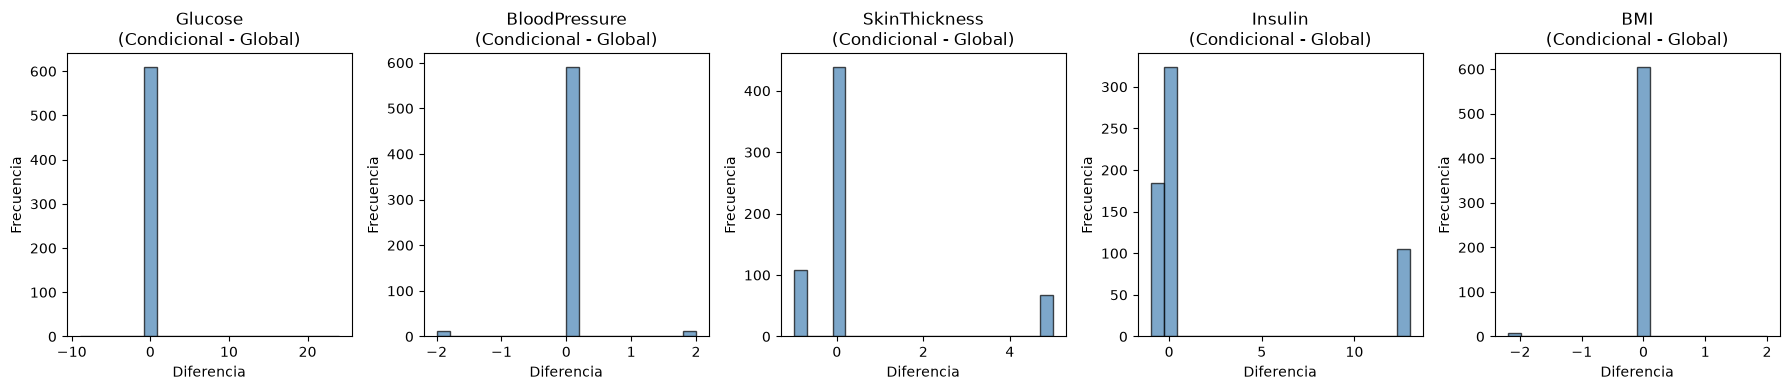

In [37]:
diferencias = diabetes_train_imputacion_cond[invalid_zero_col] - diabetes_train_imput_global[invalid_zero_col]
print("\nDiferencias (Condicional - Global):")
print(diferencias.describe())

# 4. Visualizar diferencias
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, col in enumerate(invalid_zero_col):
    axes[idx].hist(diferencias[col].dropna(), bins=20, edgecolor='k', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}\n(Condicional - Global)')
    axes[idx].set_xlabel('Diferencia')
    axes[idx].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Si bien el gráfico de diferencias muestra que la imputación condicionada y la global no siempre coinciden (sobre todo en SkinThickness e Insulin), esa diferencia por sí sola no determina cuál estrategia es mejor. La **mejor estrategia de imputación** es la que utiliza **medianas globales**, ya que, a diferencia de la imputación condicionada por Outcome, no genera fuga de información al momento de validación o prueba, y puede aplicarse de forma consistente a pacientes nuevos cuya clase todavía no se conoce.

Si las dos imputaciones dieran el mismo valor en la mayoria de los caso, se observaría la barra en cero únicamente.

## 5. Representación de los datos

Analizamos la distribución de la variable Outcome

Conteo de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Porcentaje de Outcome:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


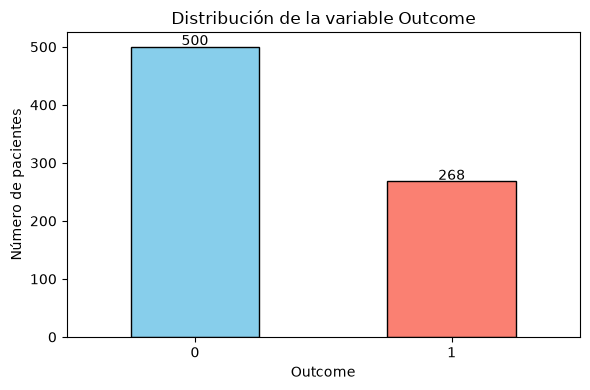

In [38]:
outcome_cont = df_diabetes["Outcome"].value_counts().sort_index() #contamos la cantidad de pacientes con y sin diabetes
outcome_por = df_diabetes["Outcome"].value_counts(normalize=True).sort_index() * 100 #calculamos el porcentaje

print("Conteo de Outcome:")
print(outcome_cont)
print("\nPorcentaje de Outcome:")
print(outcome_por.round(2))

#Graficamos la distribución de la variable Outcome
plt.figure(figsize=(6, 4))
outcome_cont.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="k")
plt.title("Distribución de la variable Outcome")
plt.xlabel("Outcome")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
for i, v in enumerate(outcome_cont):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

Como se observa en el porcentaje y en la gráfica, **las clases no estan balanceadas** ya que hay más pacientes sin diabetes que aquellos con diabetes.

# Preparación de los Datos

In [39]:
# Separamos predictores (X) y target (y), a partir de train_set y test_set --> NO de df_diabetes completo xq eso seria lo de data leakage
X_train = train_set.drop(columns=["Outcome"]).copy()
y_train = train_set["Outcome"].copy()

X_test = test_set.drop(columns=["Outcome"]).copy()
y_test = test_set["Outcome"].copy()

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90,62.0,12.0,43.0,27.2,0.580,24
711,5,126,78.0,27.0,22.0,29.6,0.439,40
373,2,105,58.0,40.0,94.0,34.9,0.225,25
46,1,146,56.0,0.0,0.0,29.7,0.564,29
682,0,95,64.0,39.0,105.0,44.6,0.366,22


In [40]:
#Reemplazamos los ceros por NaN en las columnas que no deberían tener ceros
X_train[invalid_zero_col] = X_train[invalid_zero_col].replace(0, np.nan)
X_test[invalid_zero_col] = X_test[invalid_zero_col].replace(0, np.nan)

# Verificación rápida
X_train[invalid_zero_col].isnull().sum()

Glucose            4
BloodPressure     23
SkinThickness    175
Insulin          290
BMI                9
dtype: int64

In [41]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# Ajustamos (fit) SOLO con X_train
imputer.fit(X_train)

# Transformamos ambos conjuntos con las medianas aprendidas del train
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Reconstruimos DataFrames con nombres de columnas e indice originales
X_train_prepared = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_prepared = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

X_train_prepared.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,121.671010,72.140065,29.042345,137.705212,32.448208,0.477428,33.366450
std,3.314148,30.003794,12.275119,8.891855,78.764767,6.824122,0.330300,11.833438
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.625000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


## Transformación y escalado de características


# Escalado de variables

Como se observó en la sección 2, los atributos predictores tienen escalas muy distintas entre sí (por ej, Insulin llega a valores de varios cientos, mientras que DiabetesPedigreeFunction no supera 2.5). Como se vió en clase, muchos modelos de aprendizaje automático son sensibles a esta diferencia de escala, los atributos con rangos de valores más grandes pueden dominar el entrenamiento del modelo, aunque no sean necesariamente más importantes para predecir el diagnóstico.

Para evitar esto, se aplica **StandardScaler**, que transforma cada variable para que tenga media 0 y desvío estándar 1. Se eligió por sobre MinMaxScaler porque este último comprime todos los valores entre un mínimo y un máximo fijo, lo cual lo hace muy sensible a valores extremos (outliers), y, como se vio en la sección 2, variables como Insulin presentan distribución sesgada con valores atípicos, por lo que StandardScaler resulta más robusto en este caso.

Al igual que con la imputación, el scaler se ajusta (fit) únicamente con el conjunto de entrenamiento, y luego se aplica (transform) tanto a train como a test, para evitar que estadísticas del conjunto de prueba influyan en la preparación de los datos (fuga de información).

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustamos SOLO con train, transformamos ambos
scaler.fit(X_train_prepared)
X_train_scaled = scaler.transform(X_train_prepared)
X_test_scaled = scaler.transform(X_test_prepared)

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_prepared.columns, index=X_train_prepared.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_prepared.columns, index=X_test_prepared.index)

X_train_final.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02
mean,-6.943414e-17,-1.099374e-16,3.095606e-16,-3.471707e-17,-4.339634e-18,1.649061e-16,-1.099374e-16,-1.084908e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00
min,-1.153338e+00,-2.190541e+00,-3.924957e+00,-2.480958e+00,-1.559139e+00,-2.089621e+00,-1.192094e+00,-1.045895e+00
25%,-8.513551e-01,-7.562208e-01,-6.636760e-01,-4.549828e-01,-2.249692e-01,-7.073644e-01,-7.042617e-01,-7.921693e-01
50%,-2.473897e-01,-1.558076e-01,-1.141979e-02,-4.766137e-03,-1.614373e-01,-7.070181e-03,-2.876344e-01,-3.692933e-01
75%,6.585583e-01,6.113872e-01,6.408364e-01,3.328964e-01,-9.790537e-02,5.942296e-01,4.903223e-01,6.456090e-01
max,3.980368e+00,2.579408e+00,4.065181e+00,7.874025e+00,7.703814e+00,5.081979e+00,5.610293e+00,4.028617e+00


## Conclusión

En este trabajo se identificaron valores inválidos (ceros) en variables médicas donde ese valor es fisiológicamente imposible, y se los trató como datos faltantes convirtiéndolos en NaN. Se comparó una imputación condicionada por Outcome contra una imputación por mediana global, optando por esta última ya que no genera fuga de información y es aplicable a pacientes nuevos. Los datos se dividieron en train/test de forma estratificada por Outcome, dado el desbalance de clases (65%/35%). Finalmente, se escaló el conjunto de datos con StandardScaler, ajustado solo sobre el conjunto de entrenamiento, dejando los datos listos para un futuro modelo de clasificación.